## 1. Import Required Libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, RandomizedSearchCV

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix, classification_report
)

from imblearn.over_sampling import SMOTE

import warnings
warnings.filterwarnings('ignore')

## 2. Load the Dataset

In [ ]:
df = pd.read_csv('telecom_churn_data..csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,NaN,Electronic check,70.70,151.65,Yes


## 3. Check Dataset (Shape, Columns, Data Types, Summary Statistics)

In [ ]:
print(df.shape)

(7043, 21)


In [ ]:
print(df.columns.tolist())

['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7038 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7041 non-null   object 


In [ ]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7041.000000
mean,0.162147,32.371149,64.749581
std,0.368612,24.559481,30.085731
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [ ]:
df.describe(include='object')

,customerID,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,TotalCharges,Churn
count,7043,7038,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7041,7043,7038,7043
unique,7043,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4,6526,2
top,3186-AJIEK,Male,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,20.2,No
freq,1,3550,3641,4933,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4169,2365,11,5174


## 4. Handle Missing Values

In [ ]:
print(df.isnull().sum())
print(f'\nTotal missing values: {df.isnull().sum().sum()}')

customerID          0
gender              5
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    2
PaymentMethod       0
MonthlyCharges      2
TotalCharges        5
Churn               0
dtype: int64

Total missing values: 14


In [ ]:
# Convert TotalCharges to numeric; blanks become NaN which we then impute
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Impute numerical NaNs with column median (robust to outliers)
for col in df.select_dtypes(include='number').columns:
    if df[col].isnull().sum() > 0:
        median_val = df[col].median()
        df[col].fillna(median_val, inplace=True)
        print(f'Imputed "{col}" with median = {median_val}')

# Impute categorical NaNs with mode (most frequent category─)
for col in df.select_dtypes(include='object').columns:
    if df[col].isnull().sum() > 0:
        mode_val = df[col].mode()[0]
        df[col].fillna(mode_val, inplace=True)
        print(f'Imputed "{col}" with mode = {mode_val}')

Imputed "MonthlyCharges" with median = 70.35
Imputed "TotalCharges" with median = 1397.3
Imputed "gender" with mode = Male
Imputed "PaperlessBilling" with mode = Yes


In [ ]:
print(df.isnull().sum().sum())

0


## 5. Remove Duplicate Records

In [ ]:
print(df.duplicated().sum())

0


## 6. Univariate Analysis

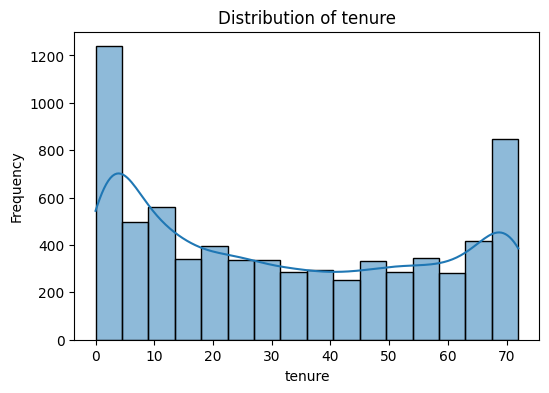

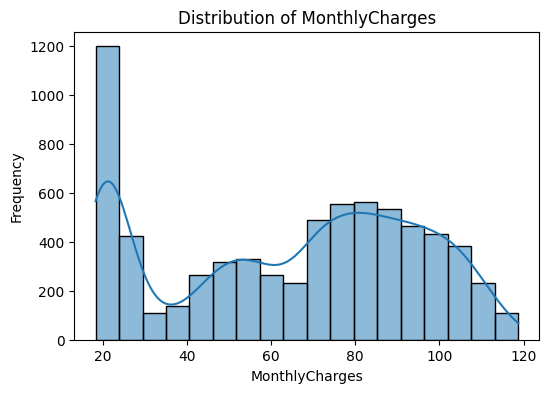

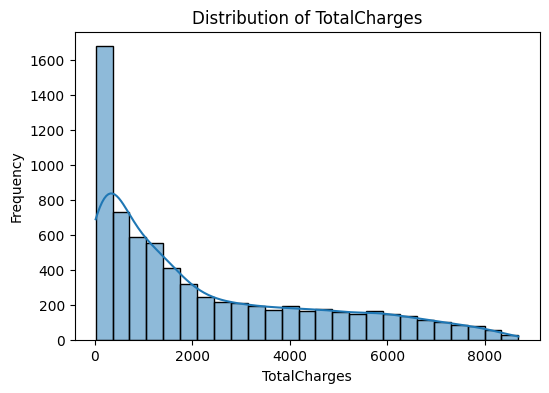

In [ ]:
# Distribution of numerical features
numerical_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

for col in numerical_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

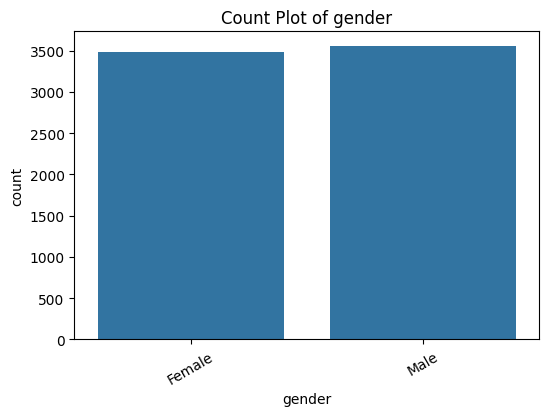

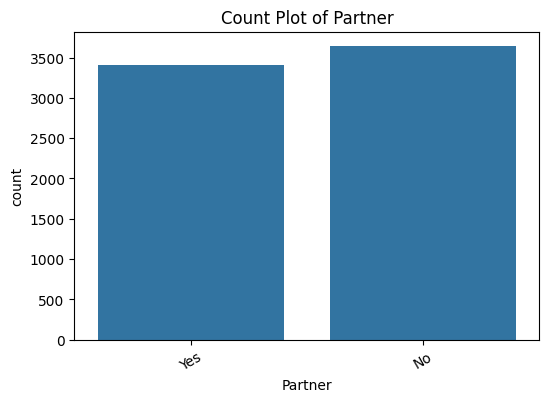

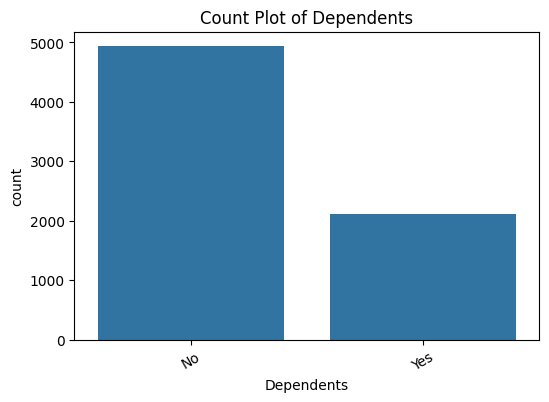

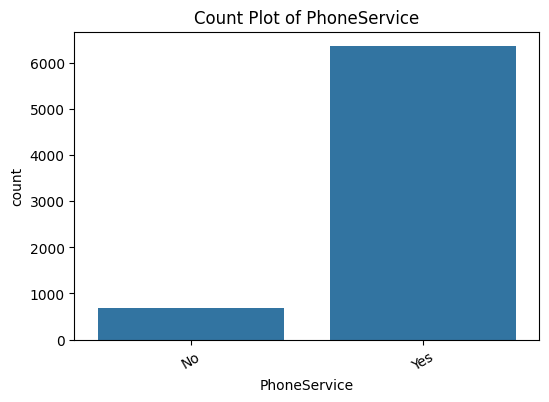

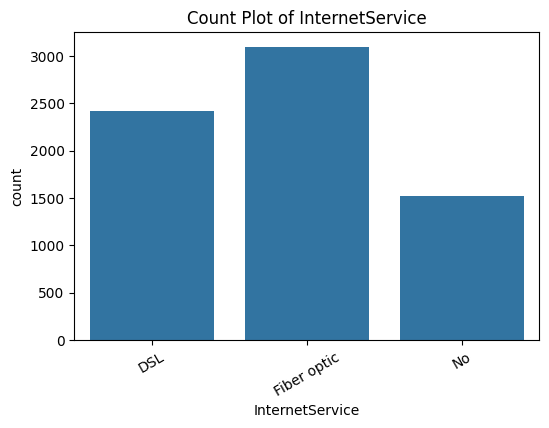

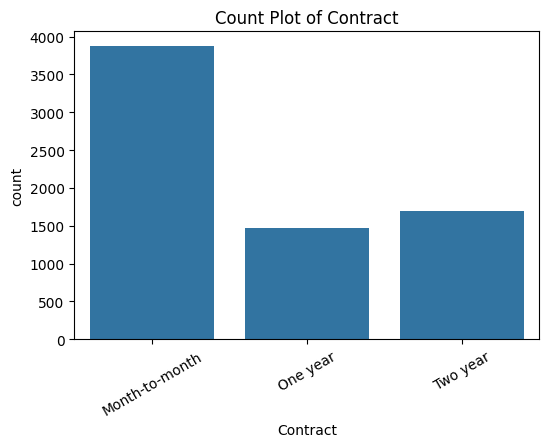

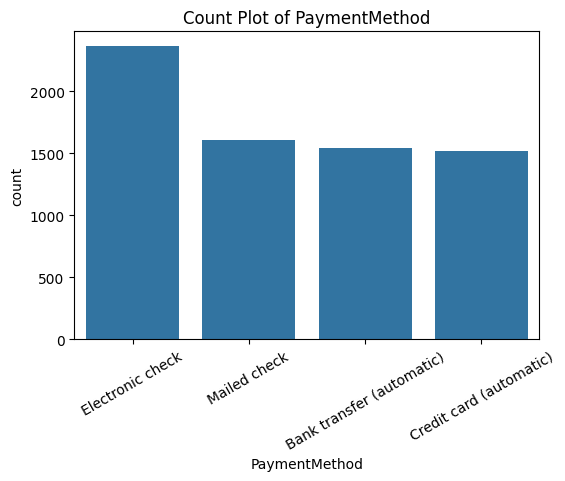

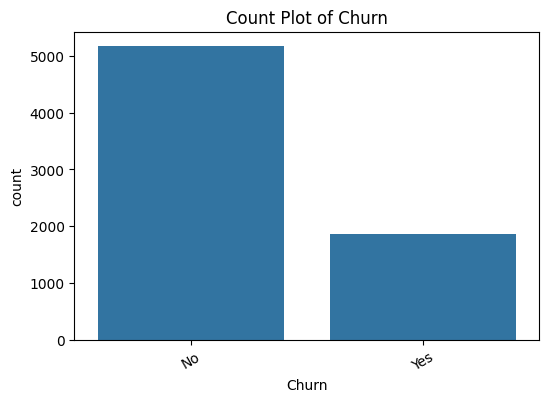

In [ ]:
# Count plots for categorical features
categorical_cols = ['gender', 'Partner', 'Dependents', 'PhoneService',
                    'InternetService', 'Contract', 'PaymentMethod', 'Churn']

for col in categorical_cols:
    plt.figure(figsize=(6,4))
    sns.countplot(x=col, data=df)
    plt.title(f"Count Plot of {col}")
    plt.xticks(rotation=30)
    plt.show()

## 7. Bivariate Analysis

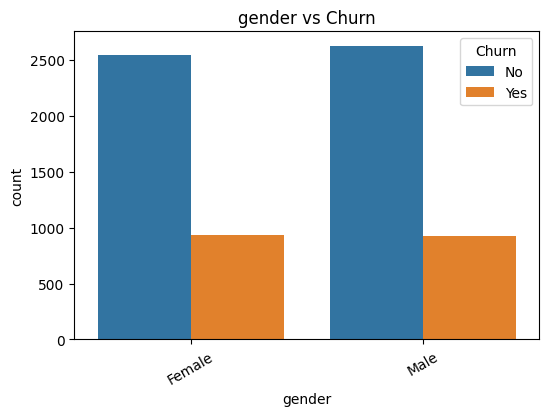

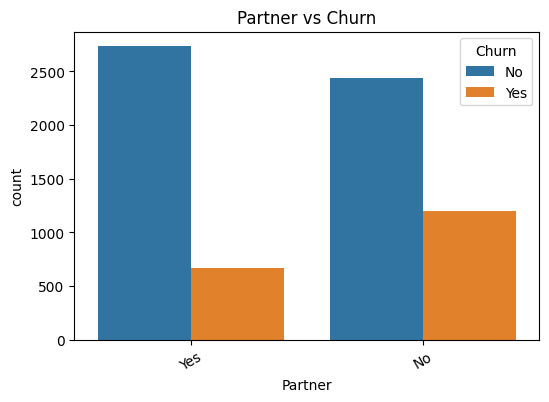

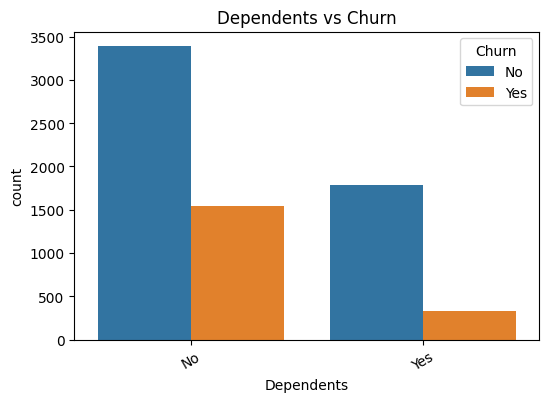

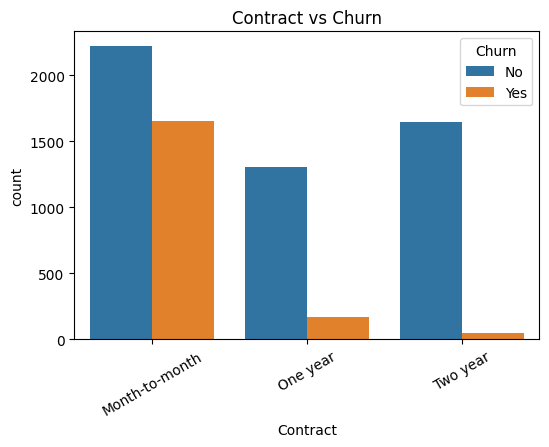

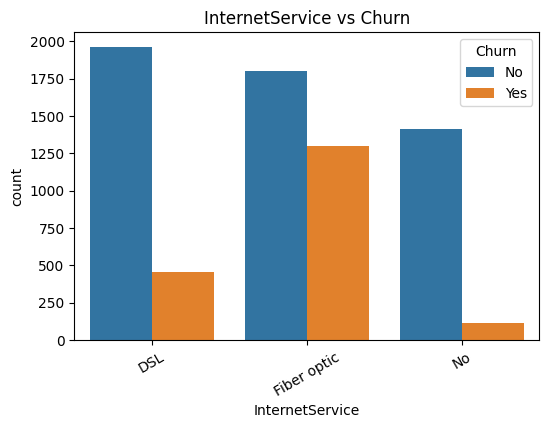

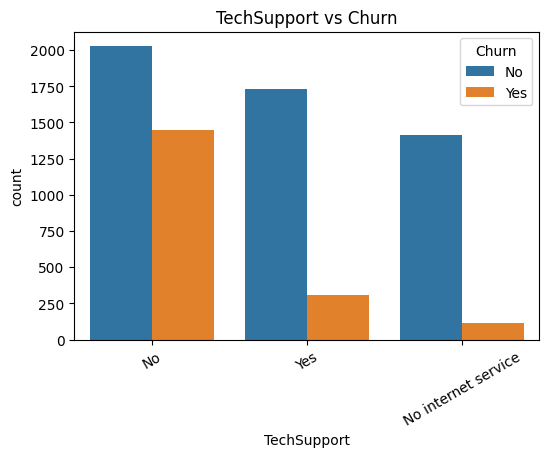

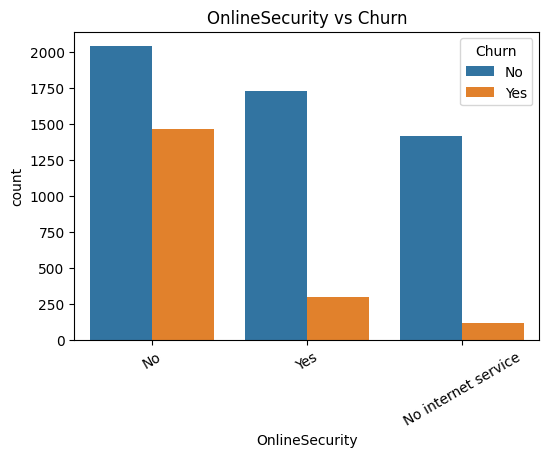

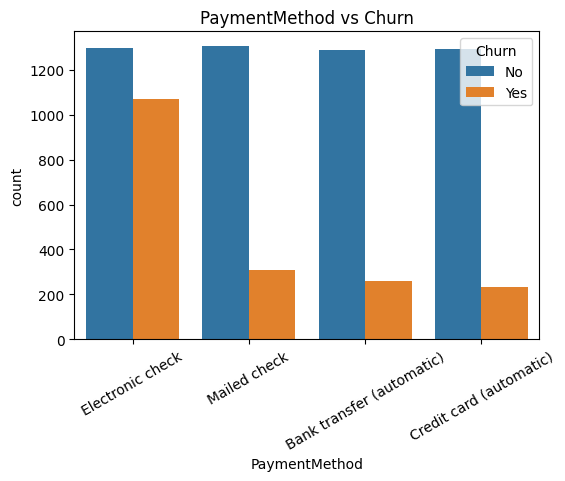

In [ ]:
# Churn vs Categorical Features
cat_features = ['gender', 'Partner', 'Dependents', 'Contract',
                'InternetService', 'TechSupport', 'OnlineSecurity', 'PaymentMethod']

for col in cat_features:
    plt.figure(figsize=(6,4))
    sns.countplot(x=col, hue='Churn', data=df)
    plt.title(f"{col} vs Churn")
    plt.xticks(rotation=30)
    plt.show()

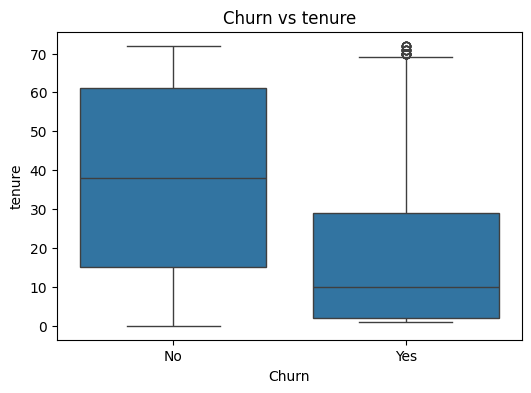

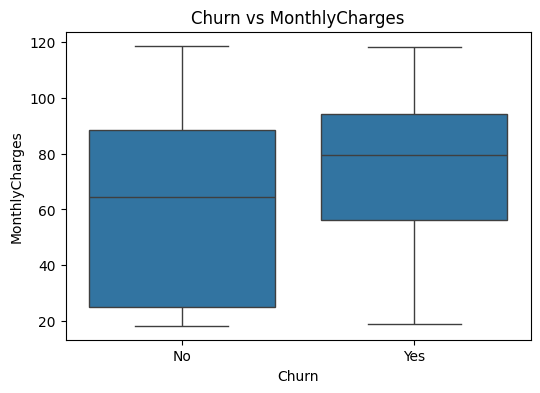

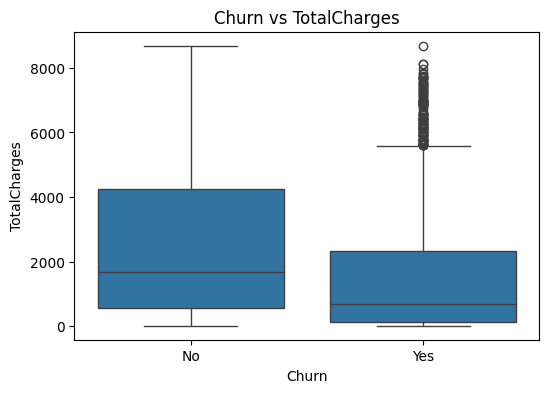

In [ ]:
# Churn vs Numerical Features
num_features = ['tenure', 'MonthlyCharges', 'TotalCharges']

for col in num_features:
    plt.figure(figsize=(6,4))
    sns.boxplot(x='Churn', y=col, data=df)
    plt.title(f"Churn vs {col}")
    plt.show()

## 8. Correlation Heatmap

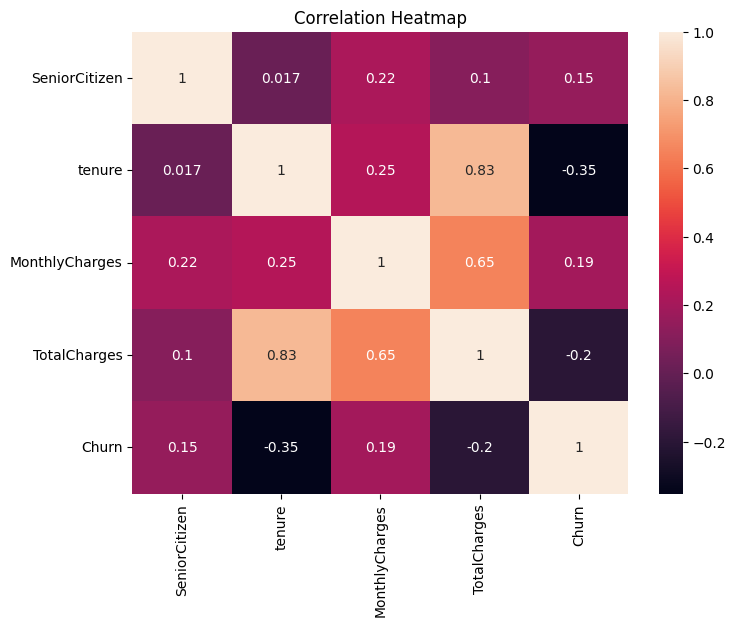

In [ ]:
# Convert Churn to numeric
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

# Select numerical columns
num_df = df.select_dtypes(include='number')

# Plot heatmap
plt.figure(figsize=(8,6))
sns.heatmap(num_df.corr(), annot=True)
plt.title("Correlation Heatmap")
plt.show()

## 9. Detect and Handle Outliers

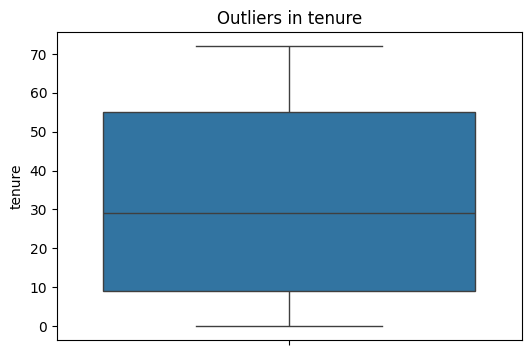

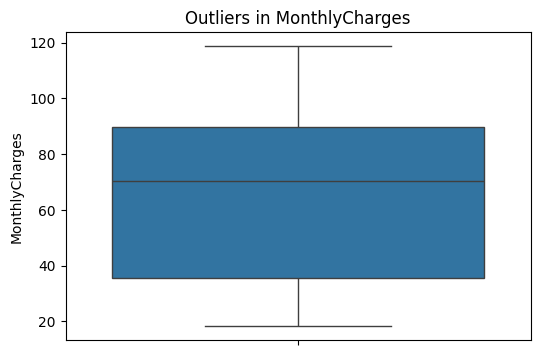

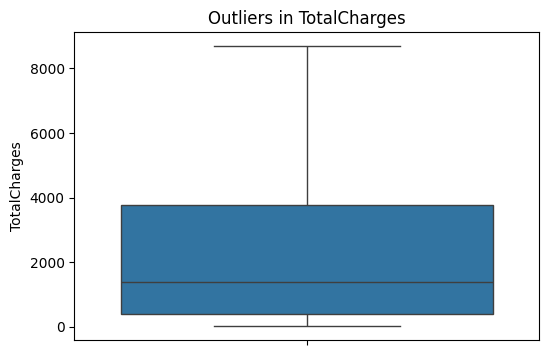

In [ ]:
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(y=df[col])
    plt.title(f"Outliers in {col}")
    plt.show()

In [ ]:
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df[col] = df[col].clip(lower, upper)

## 10. Apply Encoding (Label Encoding & One-Hot Encoding)

In [ ]:
# Drop customerID
df.drop('customerID', axis=1, inplace=True)

# Label Encoding for binary columns
le = LabelEncoder()
binary_cols = ['gender', 'Partner', 'Dependents', 'PhoneService',
               'PaperlessBilling', 'Churn']

for col in binary_cols:
    df[col] = le.fit_transform(df[col])

# One-Hot Encoding for remaining categorical columns
df = pd.get_dummies(df, drop_first=True)
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,...,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,1,0,1,29.85,29.85,0,...,False,False,False,False,False,False,False,False,True,False
1,1,0,0,0,34,1,0,56.95,1889.50,0,...,False,False,False,False,False,True,False,False,False,True
2,1,0,0,0,2,1,1,53.85,108.15,1,...,False,False,False,False,False,False,False,False,False,True
3,1,0,0,0,45,0,0,42.30,1840.75,0,...,True,False,False,False,False,True,False,False,False,False
4,0,0,0,0,2,1,1,70.70,151.65,1,...,False,False,False,False,False,False,False,False,True,False


## 11. Apply Feature Scaling

In [ ]:
cols_to_scale = ['tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen']

scaler = StandardScaler()
df[cols_to_scale] = scaler.fit_transform(df[cols_to_scale])

df[cols_to_scale].head()

,tenure,MonthlyCharges,TotalCharges,SeniorCitizen
0,-1.277445,-1.160299,-0.994109,-0.439916
1,0.066327,-0.259352,-0.173038,-0.439916
2,-1.236724,-0.362412,-0.959538,-0.439916
3,0.514251,-0.746395,-0.194562,-0.439916
4,-1.236724,0.197770,-0.940332,-0.439916


## 12.: Separate Features and Target Variable

In [ ]:
X = df.drop('Churn', axis=1)
y = df['Churn']

print("X shape:", X.shape)
print("y shape:", y.shape)

print("Churn count:")
print(y.value_counts())

X shape: (7043, 30)
y shape: (7043,)
Churn count:
Churn
0    5174
1    1869
Name: count, dtype: int64


## 13. Train-Test Split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

## 14. Handle Imbalanced Data using SMOTE

In [ ]:
print("Before SMOTE:")
print(y_train.value_counts())

smote = SMOTE()
X_train, y_train = smote.fit_resample(X_train, y_train)

print("After SMOTE:")
print(y_train.value_counts())

Before SMOTE:
Churn
0    4139
1    1495
Name: count, dtype: int64
After SMOTE:
Churn
0    4139
1    4139
Name: count, dtype: int64


## 15. Train Classification Models

In [ ]:
models = {
    'Logistic': LogisticRegression(),
    'KNN': KNeighborsClassifier(),
    'DecisionTree': DecisionTreeClassifier(),
    'RandomForest': RandomForestClassifier(),
    'SVC': SVC(probability=True),
    'GradientBoost': GradientBoostingClassifier(),
    'XGBoost': XGBClassifier()
}

## 16. Evaluate Models Evaluate Models using Accuracy, Precision, Recall, F1 Score, ROC-AUC Score, Confusion Matrix

In [ ]:
def evaluate_model(model):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:,1]
    else:
        y_prob = y_pred

    return {
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_prob)
    }

results = {}

for name, model in models.items():
    results[name] = evaluate_model(model)

print("All models trained")
pd.DataFrame(results).T

All models trained


,Accuracy,Precision,Recall,F1,ROC-AUC
Logistic,0.743080,0.511494,0.713904,0.595982,0.824436
KNN,0.718950,0.480287,0.716578,0.575107,0.784442
DecisionTree,0.706884,0.458422,0.574866,0.510083,0.664522
RandomForest,0.767211,0.553738,0.633690,0.591022,0.819847
SVC,0.757275,0.530769,0.737968,0.617450,0.818401
GradientBoost,0.744500,0.512774,0.751337,0.609544,0.834925
XGBoost,0.760823,0.541573,0.644385,0.588523,0.805656


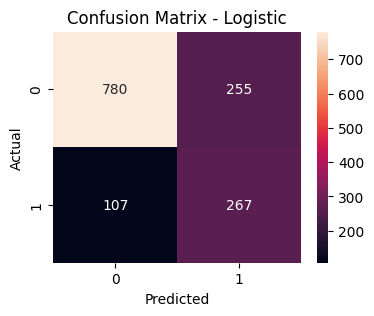

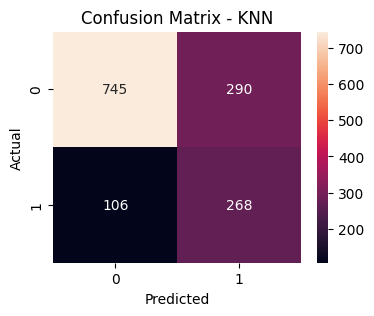

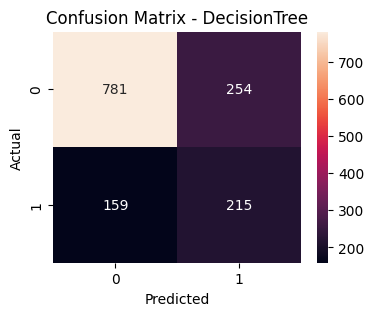

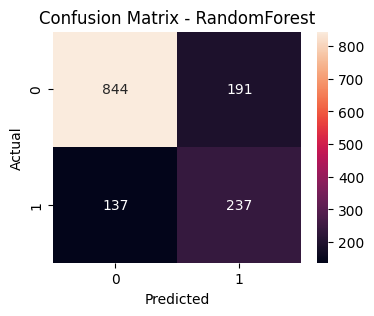

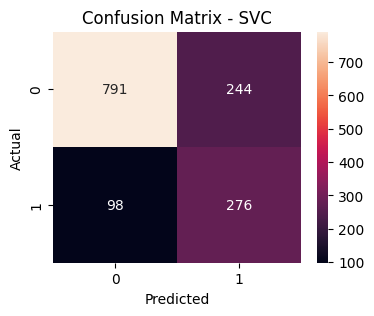

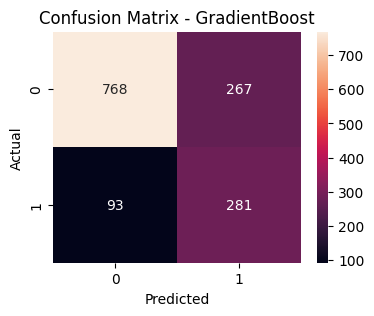

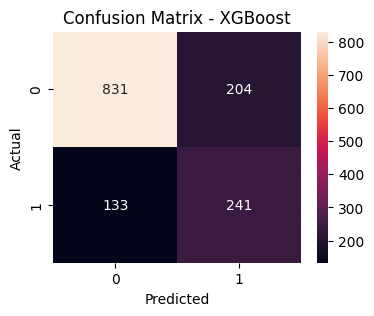

In [ ]:
# Confusion matrix
for name, model in models.items():
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(4,3))
    sns.heatmap(cm, annot=True, fmt='d')
    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

In [ ]:
# classification reports for each model
for name, model in trained_models.items():
    y_pred = model.predict(X_test)

    print("\n")
    print(name)
    print(classification_report(y_test, y_pred))



Logistic Regression
              precision    recall  f1-score   support

           0       0.88      0.75      0.81      1035
           1       0.51      0.71      0.59       374

    accuracy                           0.74      1409
   macro avg       0.69      0.73      0.70      1409
weighted avg       0.78      0.74      0.75      1409



K-Nearest Neighbors
              precision    recall  f1-score   support

           0       0.88      0.72      0.79      1035
           1       0.48      0.72      0.58       374

    accuracy                           0.72      1409
   macro avg       0.68      0.72      0.69      1409
weighted avg       0.77      0.72      0.74      1409



Decision Tree
              precision    recall  f1-score   support

           0       0.84      0.77      0.80      1035
           1       0.48      0.60      0.54       374

    accuracy                           0.72      1409
   macro avg       0.66      0.68      0.67      1409
weighted avg  

## 17. Hyperparameter Tuning (GridSearchCV & RandomizedSearchCV)

In [ ]:
# GridSearchCV on Random Forest
params = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10],
    'min_samples_split': [2, 5]
}

grid = GridSearchCV(RandomForestClassifier(), params, cv=3)

grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)
print("Best Score:", grid.best_score_)

Best Parameters: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}
Best Score: 0.8367990222600431


In [ ]:
# RandomizedSearchCV on XGBoost
params = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1]
}

random_search = RandomizedSearchCV(XGBClassifier(), params, n_iter=5, cv=3)

random_search.fit(X_train, y_train)

print("Best Parameters:", random_search.best_params_)
print("Best Score:", random_search.best_score_)

Best Parameters: {'n_estimators': 100, 'max_depth': 7, 'learning_rate': 0.1}
Best Score: 0.8174724178927812


In [ ]:
# Evaluate tuned models
models_tuned = {
    'RandomForest': grid.best_estimator_,
    'XGBoost': random_search.best_estimator_
}

for name, model in models_tuned.items():
    y_pred = model.predict(X_test)

    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:,1]
    else:
        y_prob = y_pred

    print("\n", name)
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred))
    print("Recall:", recall_score(y_test, y_pred))
    print("F1:", f1_score(y_test, y_pred))
    print("ROC-AUC:", roc_auc_score(y_test, y_prob))


 RandomForest
Accuracy: 0.7643718949609652
Precision: 0.5483870967741935
Recall: 0.6363636363636364
F1: 0.5891089108910891
ROC-AUC: 0.8199643493761141

 XGBoost
Accuracy: 0.7558552164655784
Precision: 0.53099173553719
Recall: 0.6871657754010695
F1: 0.5990675990675991
ROC-AUC: 0.824710015758609


## 18. Compare Model Performance

In [ ]:
results_df = pd.DataFrame(results).T   # IMPORTANT: transpose

results_df = results_df.sort_values('F1', ascending=False)

print("Model Comparison:")
print(results_df)

Model Comparison:
               Accuracy  Precision    Recall        F1   ROC-AUC
SVC            0.757275   0.530769  0.737968  0.617450  0.818401
GradientBoost  0.744500   0.512774  0.751337  0.609544  0.834925
Logistic       0.743080   0.511494  0.713904  0.595982  0.824436
RandomForest   0.767211   0.553738  0.633690  0.591022  0.819847
XGBoost        0.760823   0.541573  0.644385  0.588523  0.805656
KNN            0.718950   0.480287  0.716578  0.575107  0.784442
DecisionTree   0.706884   0.458422  0.574866  0.510083  0.664522


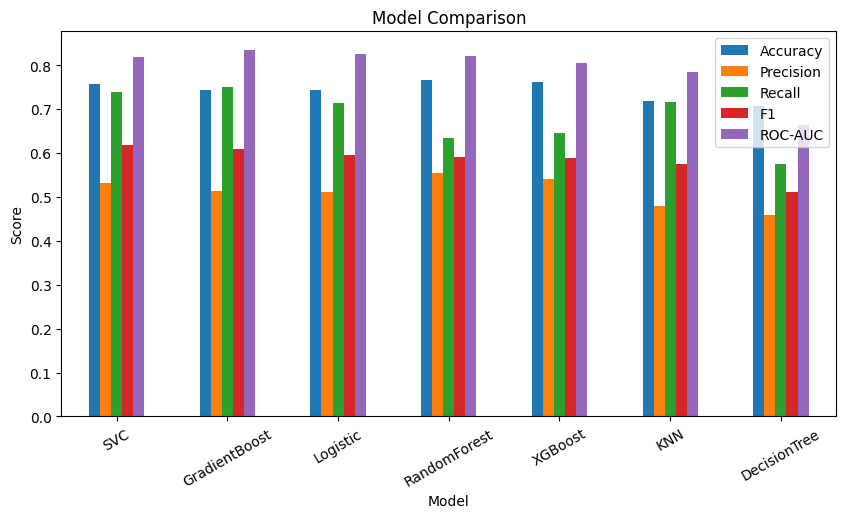

In [ ]:
metrics = ['Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC']

plot_df = results_df[metrics]

plot_df.plot(kind='bar', figsize=(10,5))

plt.title("Model Comparison")
plt.xlabel("Model")
plt.ylabel("Score")
plt.xticks(rotation=30)
plt.show()

## 19. Select Best Model

In [ ]:
best_row = results_df.iloc[0]
best_name = best_row.name

print('Best Performing Model')
print('----------------------')
print('Model     :', best_name)
print('Accuracy  :', best_row['Accuracy'])
print('Precision :', best_row['Precision'])
print('Recall    :', best_row['Recall'])
print('F1 Score  :', best_row['F1'])
print('ROC-AUC   :', best_row['ROC-AUC'])

Best Performing Model
----------------------
Model     : SVC
Accuracy  : 0.7572746628814763
Precision : 0.5307692307692308
Recall    : 0.7379679144385026
F1 Score  : 0.6174496644295302
ROC-AUC   : 0.8184014053579272


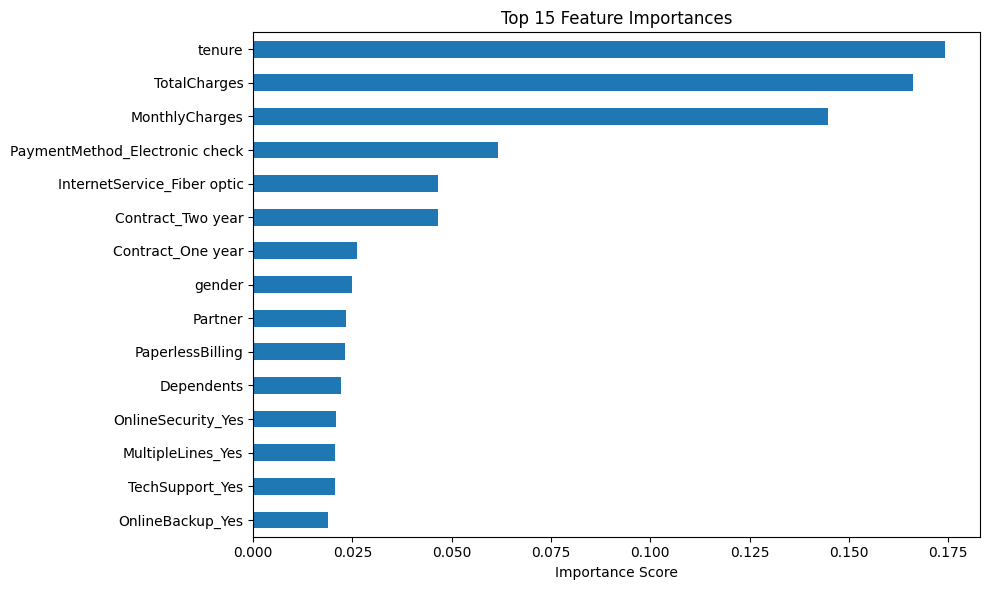

In [ ]:
best_model_obj = grid_rf.best_estimator_

feat_imp = pd.Series(best_model_obj.feature_importances_, index=X.columns)
feat_imp_top = feat_imp.nlargest(15).sort_values()

plt.figure(figsize=(10, 6))
feat_imp_top.plot(kind='barh')
plt.title('Top 15 Feature Importances')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

In [ ]:
cv_scores = cross_val_score(best_model_obj, X, y, cv=5, scoring='f1')

print('Cross-Validation F1 Scores (5-Fold):', cv_scores.round(4))
print('Mean F1 :', round(cv_scores.mean(), 4), '±', round(cv_scores.std(), 4))

Cross-Validation F1 Scores (5-Fold): [0.5427 0.5566 0.5112 0.5597 0.5537]
Mean F1 : 0.5448 ± 0.0177


## 20. Final Insights & Business Recommendations

In [ ]:
print("""
FINAL INSIGHTS — CUSTOMER CHURN PREDICTION

Key Factors Influencing Churn:
1. Contract Type  : Month-to-month customers churn most
2. Monthly Charges: High charges lead to higher churn
3. Tenure         : Short-tenure customers are high-risk
4. TechSupport    : Customers without TechSupport churn more
5. OnlineSecurity : No security service increases churn risk
6. PaymentMethod  : Electronic check users churn more
7. Fiber optic    : Higher churn than DSL or no internet

Business Recommendations:
- Offer discounts to convert month-to-month to long-term contracts
- Bundle TechSupport and OnlineSecurity services
- Focus on customers in their first 12 months
- Provide personalized offers for high-charge customers
- Encourage auto-pay instead of electronic check
- Use the model regularly to identify at-risk customers
- Create loyalty rewards for long-term customers
""")


FINAL INSIGHTS — CUSTOMER CHURN PREDICTION

Key Factors Influencing Churn:
1. Contract Type  : Month-to-month customers churn most
2. Monthly Charges: High charges lead to higher churn
3. Tenure         : Short-tenure customers are high-risk
4. TechSupport    : Customers without TechSupport churn more
5. OnlineSecurity : No security service increases churn risk
6. PaymentMethod  : Electronic check users churn more
7. Fiber optic    : Higher churn than DSL or no internet

Business Recommendations:
- Offer discounts to convert month-to-month to long-term contracts
- Bundle TechSupport and OnlineSecurity services
- Focus on customers in their first 12 months
- Provide personalized offers for high-charge customers
- Encourage auto-pay instead of electronic check
- Use the model regularly to identify at-risk customers
- Create loyalty rewards for long-term customers



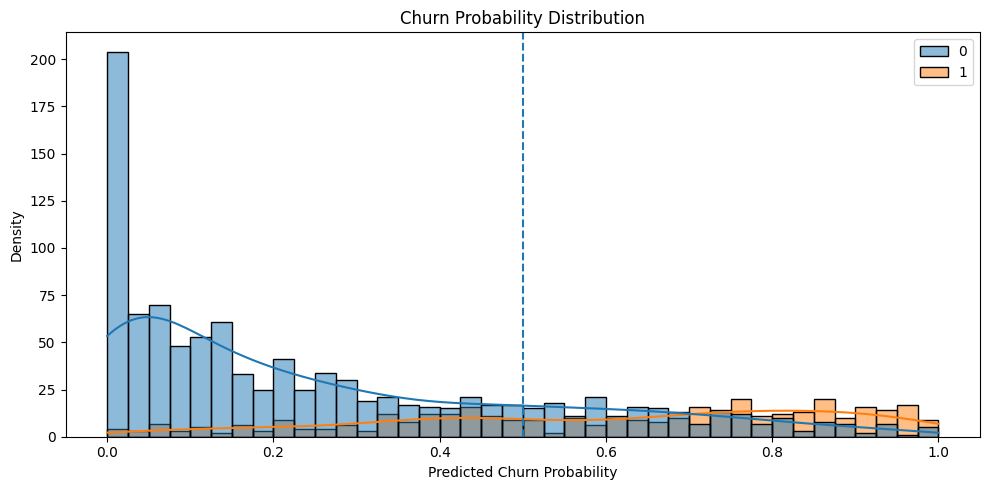

In [ ]:
y_proba_final = best_model_obj.predict_proba(X_test)[:, 1]

plt.figure(figsize=(10, 5))
sns.histplot(x=y_proba_final, hue=y_test.values, kde=True, bins=40)

plt.axvline(0.5, linestyle='--')
plt.title('Churn Probability Distribution')
plt.xlabel('Predicted Churn Probability')
plt.ylabel('Density')

plt.tight_layout()
plt.show()